In [ ]:
import json

# ==== Load JSON Data ====
embedding_file = "/content/drive/MyDrive/PINN/Dataset_Preparation/Anish/Abhimany_role_tagged.json"
with open(embedding_file, "r") as f:
    embedding_data = json.load(f)

# ==== Filter and Structure Dataset (Only for Abhimanyu) ====
samples = []
for entry in embedding_data:
    if entry.get("character", "").lower() != "abhimanyu":
        continue
    parva = entry.get("parva", 0)
    chapter = entry.get("chapter", 0)
    sentence = entry.get("sentence_number", 0)
    for i in range(1, 13):
        key = f"layer_{i}"
        if key in entry["embeddings"]:
            embedding = entry["embeddings"][key]
            samples.append({
                "meta": [float(parva), float(chapter), float(sentence), float(i)],
                "embedding": embedding,
                "sentence": sentence,
                "layer": i
            })

# ==== Sort by parva, chapter, sentence, then layer ====
samples.sort(key=lambda x: (x["meta"][0], x["meta"][1], x["meta"][2], x["layer"]))

# ==== Generate and Print Formatted Output ====
for i in range(len(samples) - 1):
    curr = samples[i]
    next_ = samples[i + 1]
    if curr["sentence"] == next_["sentence"] and next_["layer"] == curr["layer"] + 1:
        meta = [f"{v:.6f}" for v in curr["meta"]]
        input_embed_5 = [f"{v:.6f}" for v in curr["embedding"][:5]]
        output_embed_5 = [f"{v:.6f}" for v in next_["embedding"][:5]]

        print(f"Input: [{', '.join(meta)}, [{', '.join(input_embed_5)}]] → [{', '.join(output_embed_5)}]")


In [2]:
from sklearn.model_selection import train_test_split

# Extract input and output pairs for PINN
X = []
Y = []

for i in range(len(samples) - 1):
    curr = samples[i]
    next_ = samples[i + 1]
    if curr["sentence"] == next_["sentence"] and next_["layer"] == curr["layer"] + 1:
        input_vector = curr["meta"] + curr["embedding"]  # meta: [parva, chapter, sentence, layer]
        output_vector = next_["embedding"]               # target: next layer's embedding
        X.append(input_vector)
        Y.append(output_vector)

# Split 80:20
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [3]:
print(X_train[0])
print(len(X_train[0]))

[6.0, 3.0, 4763.0, 1.0, -0.15696193277835846, 0.5229920148849487, -0.7442228198051453, -0.130194753408432, 0.21285876631736755, -1.4037253856658936, 0.8170124292373657, 0.5955127477645874, -0.2766045331954956, 0.34440353512763977, 0.10638810694217682, -0.03329212963581085, -0.3761240839958191, -0.09261137247085571, -0.3873196244239807, -0.12650363147258759, 0.07363783568143845, -0.28778180480003357, -0.7187278270721436, 0.40193063020706177, -0.24416226148605347, -0.87542724609375, 0.11805382370948792, 0.016747169196605682, -0.38701558113098145, 0.014044875279068947, -0.24684208631515503, -0.1808975338935852, -0.6863203644752502, 0.4160762131214142, -0.287177175283432, -0.11520995944738388, -0.331969290971756, -0.3675234019756317, 0.21853326261043549, 0.060623884201049805, -0.294202983379364, 0.4863263666629791, 0.010090559720993042, -0.5502352118492126, -0.14701277017593384, -0.6520895957946777, 0.4678550958633423, -0.30895692110061646, -0.3624023199081421, -0.4434317648410797, -0.1739

# **PARVA-WISE dataset Preparation and PINN model Training**

In [4]:
import json
import random
from collections import defaultdict

# ==== Load JSON ====
embedding_file = "/content/drive/MyDrive/PINN/Dataset_Preparation/Anish/Abhimany_role_tagged.json"
with open(embedding_file, "r") as f:
    embedding_data = json.load(f)

# ==== Group Samples by (parva, chapter, sentence_number) ====
sentence_groups = defaultdict(list)

for entry in embedding_data:
    if entry.get("character", "").lower() != "abhimanyu":
        continue
    parva = entry.get("parva", 0)
    chapter = entry.get("chapter", 0)
    sentence = entry.get("sentence_number", 0)
    for i in range(1, 13):
        key = f"layer_{i}"
        if key in entry["embeddings"]:
            embedding = entry["embeddings"][key]
            sentence_groups[(parva, chapter, sentence)].append({
                "meta": [float(parva), float(chapter), float(sentence), float(i)],
                "embedding": embedding,
                "sentence": sentence,
                "layer": i,
                "parva": parva
            })

# ==== Group by Parva ====
parva_to_sentences = defaultdict(list)
for key, group in sentence_groups.items():
    parva = key[0]
    if len(group) == 12:  # only include full 12-layer sentences
        parva_to_sentences[parva].append(group)

# ==== Split Parvas into Train/Test (80:20) ====
all_parvas = sorted(parva_to_sentences.keys())
random.seed(42)
random.shuffle(all_parvas)

split_index = int(0.8 * len(all_parvas))
train_parvas = set(all_parvas[:split_index])
test_parvas = set(all_parvas[split_index:])

# ==== Construct Train/Test Sets ====
train_set, test_set = [], []

for parva in train_parvas:
    for sentence_group in parva_to_sentences[parva]:
        train_set.extend(sentence_group)

for parva in test_parvas:
    for sentence_group in parva_to_sentences[parva]:
        test_set.extend(sentence_group)

# ==== Final Output ====
print(f"Total full sentences: {sum(len(v) for v in parva_to_sentences.values())}")
print(f"Train sentences: {len(train_set) // 12} (Total embeddings: {len(train_set)})")
print(f"Test sentences:  {len(test_set) // 12} (Total embeddings: {len(test_set)})")

# ==== Print Parvas in Train and Test Set ====
print("\n==== TRAINING PARVAS ====")
print(sorted(train_parvas))

print("\n==== TEST PARVAS ====")
print(sorted(test_parvas))


# ==== Helper: Print Sample from Dataset ====
def print_sample(name, dataset, count=5):
    print(f"\n==== {name.upper()} SAMPLE ({count} entries) ====")
    shown = 0
    seen_sentences = set()
    for item in dataset:
        key = (item["meta"][0], item["meta"][1], item["meta"][2])  # (parva, chapter, sentence)
        if key not in seen_sentences:
            seen_sentences.add(key)
            print(f"Parva: {item['meta'][0]}, Chapter: {item['meta'][1]}, Sentence: {item['meta'][2]}, Layer: {item['meta'][3]}")
            print(f"Embedding (first 5 dims): {[round(v, 6) for v in item['embedding'][:5]]}")
            print("-" * 60)
            shown += 1
        if shown == count:
            break

# ==== Show Sample Entries ====
print_sample("train", train_set, count=5)
print_sample("test", test_set, count=5)




# ==== Optional: Save to file ====
# with open("train_data.json", "w") as f:
#     json.dump(train_set, f, indent=2)
# with open("test_data.json", "w") as f:
#     json.dump(test_set, f, indent=2)


Total full sentences: 351
Train sentences: 299 (Total embeddings: 3588)
Test sentences:  52 (Total embeddings: 624)

==== TRAINING PARVAS ====
[4, 5, 6, 7, 8, 9, 11, 12, 15, 18]

==== TEST PARVAS ====
[1, 3, 14]

==== TRAIN SAMPLE (5 entries) ====
Parva: 4.0, Chapter: 4.0, Sentence: 2769.0, Layer: 1.0
Embedding (first 5 dims): [0.032954, 0.496022, -0.960996, -0.130763, -0.085555]
------------------------------------------------------------
Parva: 4.0, Chapter: 4.0, Sentence: 2776.0, Layer: 1.0
Embedding (first 5 dims): [-0.056908, 0.371795, -0.858685, -0.209814, -0.023691]
------------------------------------------------------------
Parva: 4.0, Chapter: 4.0, Sentence: 2781.0, Layer: 1.0
Embedding (first 5 dims): [-0.211669, 0.553795, -0.680871, 0.07618, 0.058214]
------------------------------------------------------------
Parva: 4.0, Chapter: 4.0, Sentence: 2783.0, Layer: 1.0
Embedding (first 5 dims): [-0.267743, 0.75908, -0.781082, 0.015893, 0.079225]
--------------------------------

In [5]:
import json
import random
from collections import defaultdict

# ==== STEP 1: Load JSON data ====
# The input JSON contains sentence-wise BERT embeddings for Abhimanyu,
# where each sentence may contain embeddings from all 12 BERT layers.
embedding_file = "/content/drive/MyDrive/PINN/Dataset_Preparation/Anish/Abhimany_role_tagged.json"
with open(embedding_file, "r") as f:
    embedding_data = json.load(f)

# ==== STEP 2: Group by sentence (identified by parva, chapter, sentence_number) ====
# Each sentence must have exactly 12 layers (layer_1 to layer_12) to be considered valid.
# We collect each of the 12 layer embeddings into a single list under a unique sentence key.
sentence_groups = defaultdict(list)
for entry in embedding_data:
    if entry.get("character", "").lower() != "abhimanyu":
        continue
    parva = entry.get("parva", 0)
    chapter = entry.get("chapter", 0)
    sentence = entry.get("sentence_number", 0)
    for i in range(1, 13):
        key = f"layer_{i}"
        if key in entry["embeddings"]:
            embedding = entry["embeddings"][key]
            sentence_groups[(parva, chapter, sentence)].append({
                "meta": [float(parva), float(chapter), float(sentence), float(i)],
                "embedding": embedding,
                "layer": i
            })

# ==== STEP 3: Keep only complete sentences ====
# We retain only those sentence groups that contain exactly 12 layers (from 1 to 12).
complete_sentences = {k: v for k, v in sentence_groups.items() if len(v) == 12}

# ==== STEP 4: Organize sentence keys by parva ====
# For parva-wise splitting, we group sentence keys by their parva ID.
parva_to_keys = defaultdict(list)
for (parva, chapter, sentence) in complete_sentences:
    parva_to_keys[parva].append((parva, chapter, sentence))

# ==== STEP 5: Split parvas into train/test (80% : 20%) ====
# We shuffle and split the unique parvas, and based on that, assign all their sentences to train or test.
all_parvas = sorted(parva_to_keys.keys())
random.seed(42)  # Ensures reproducibility
random.shuffle(all_parvas)

split_index = int(0.8 * len(all_parvas))
train_parvas = set(all_parvas[:split_index])
test_parvas = set(all_parvas[split_index:])

# ==== STEP 6: Get sentence keys assigned to train and test ====
# Based on the parva split, assign all sentences of that parva to the respective set.
train_keys, test_keys = [], []
for p in train_parvas:
    train_keys.extend(parva_to_keys[p])
for p in test_parvas:
    test_keys.extend(parva_to_keys[p])

# ==== Summary ====
print("\n==== PARVA-WISE SPLIT ====")
print(f"Train Parvas: {sorted(train_parvas)}")
print(f"Test Parvas:  {sorted(test_parvas)}")
print(f"Train Sentences: {len(train_keys)}")
print(f"Test Sentences:  {len(test_keys)}")

# ==== STEP 7: Create (X, Y) pairs for each sentence ====
# For each sentence (which contains 12 layers), we construct 11 training samples:
# One for each consecutive pair: (layer_1 → layer_2), (layer_2 → layer_3), ..., (layer_11 → layer_12)
# Each X = [meta (4), embedding of layer l (768)] → size 772
# Each Y = embedding of layer l+1 (768)
def build_xy(keys, source_dict):
    X, Y = [], []
    for key in keys:
        layers = sorted(source_dict[key], key=lambda x: x["layer"])
        for i in range(11):  # From layer 1 to 11
            meta = layers[i]["meta"]                 # meta = [parva, chapter, sentence, layer]
            input_embed = layers[i]["embedding"]     # E(l)
            output_embed = layers[i+1]["embedding"]  # E(l+1)
            X.append(meta + input_embed)             # Input: meta + E(l)
            Y.append(output_embed)                   # Output: E(l+1)
    return X, Y

# ==== STEP 8: Build X_train, Y_train, X_test, Y_test ====
X_train, Y_train = build_xy(train_keys, complete_sentences)
X_test, Y_test = build_xy(test_keys, complete_sentences)

# ==== Final summary ====
print("\n==== FINAL X/Y SPLITS ====")
print(f"X_train: {len(X_train)} samples")
print(f"Y_train: {len(Y_train)} targets")
print(f"X_test:  {len(X_test)} samples")
print(f"Y_test:  {len(Y_test)} targets")

# ==== Sample print for sanity check ====
print("\nSample X_train[0]:")
print(f"Meta + Embed (first 8 dims): {[round(v, 6) for v in X_train[0][:8]]} ... total {len(X_train[0])} dims")

print("\nSample Y_train[0]:")
print(f"Target Embed (first 5 dims): {[round(v, 6) for v in Y_train[0][:5]]}")



==== PARVA-WISE SPLIT ====
Train Parvas: [4, 5, 6, 7, 8, 9, 11, 12, 15, 18]
Test Parvas:  [1, 3, 14]
Train Sentences: 299
Test Sentences:  52

==== FINAL X/Y SPLITS ====
X_train: 3289 samples
Y_train: 3289 targets
X_test:  572 samples
Y_test:  572 targets

Sample X_train[0]:
Meta + Embed (first 8 dims): [4.0, 4.0, 2769.0, 1.0, 0.032954, 0.496022, -0.960996, -0.130763] ... total 772 dims

Sample Y_train[0]:
Target Embed (first 5 dims): [0.017399, 0.672189, -0.557281, -0.052896, 0.087075]


# **Define the PINN Model in PyTorch for Parvawise Split**

In [6]:
import torch
import torch.nn as nn
import torch.autograd as autograd

class EmbeddingDynamicsPINN(nn.Module):
    def __init__(self, input_dim=772, output_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        return self.net(x)

    def compute_derivative(self, x):
        # x must require gradient
        y = self.forward(x)
        dy_dx = autograd.grad(
            outputs=y,
            inputs=x,
            grad_outputs=torch.ones_like(y),
            create_graph=True,
            retain_graph=True,
            only_inputs=True
        )[0]
        return y, dy_dx


# **Prepare Data for Training for Parvawise Split**

In [7]:
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

# Convert X, Y to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


# **Training Setup with Losses  and Training Loop (with Physics-Informed Loss)  for Parvawise Split**

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EmbeddingDynamicsPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
mse_loss = nn.MSELoss()

# Physics loss weights
λ_data = 1.0
λ_smooth = 1.0
λ_consist = 1.0
λ_norm = 0.1

# for epoch in range(1, 1001):
for epoch in range(1, 31):
    model.train()
    total_loss = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device).requires_grad_(True)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        pred_y, grad = model.compute_derivative(batch_x)

        # === Data Loss ===
        loss_data = mse_loss(pred_y, batch_y)

        # === Norm Conservation Loss ===
        norm_diff = torch.norm(pred_y, dim=1) - torch.norm(batch_x[:, 4:], dim=1)
        loss_norm = torch.mean(norm_diff ** 2)

        # === Narrative Consistency Loss ===
        grad_meta = grad[:, 0:3]  # derivatives w.r.t parva, chapter, sentence
        loss_consist = torch.mean(grad_meta ** 2)

        # === Smoothness Loss ===
        grad_layer = grad[:, 3].unsqueeze(1)  # dE/dl
        # Numerical 2nd-order smoothness approximation isn't feasible here without triplets
        loss_smooth = torch.mean(grad_layer ** 2)

        # === Total Loss ===
        loss = (λ_data * loss_data +
                λ_norm * loss_norm +
                λ_consist * loss_consist +
                λ_smooth * loss_smooth)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # if epoch % 100 == 0 or epoch == 1:
    if epoch % 1 == 0 or epoch == 1:
        print(f"Epoch {epoch}: Total Loss = {total_loss:.6f}, Data = {loss_data.item():.6f}, Norm = {loss_norm.item():.6f}, Consistency = {loss_consist.item():.6f}, Smooth = {loss_smooth.item():.6f}")


Epoch 1: Total Loss = 6435.777989, Data = 0.464963, Norm = 10.259316, Consistency = 0.000256, Smooth = 0.000068
Epoch 2: Total Loss = 115.708651, Data = 0.547690, Norm = 0.280853, Consistency = 0.000070, Smooth = 0.000078
Epoch 3: Total Loss = 53.000122, Data = 0.460519, Norm = 0.119279, Consistency = 0.000049, Smooth = 0.000040
Epoch 4: Total Loss = 44.645581, Data = 0.390546, Norm = 0.269740, Consistency = 0.000030, Smooth = 0.000053
Epoch 5: Total Loss = 37.766053, Data = 0.312459, Norm = 0.243100, Consistency = 0.000052, Smooth = 0.000055
Epoch 6: Total Loss = 30.652317, Data = 0.232016, Norm = 0.059289, Consistency = 0.000047, Smooth = 0.000038
Epoch 7: Total Loss = 24.012154, Data = 0.170701, Norm = 0.125611, Consistency = 0.000116, Smooth = 0.000027
Epoch 8: Total Loss = 19.827044, Data = 0.146526, Norm = 0.915911, Consistency = 0.000060, Smooth = 0.000016
Epoch 9: Total Loss = 17.091410, Data = 0.149655, Norm = 0.073397, Consistency = 0.000057, Smooth = 0.000018
Epoch 10: Total

# **Evaluate+Visualize Error Distribution on Test Set for Parvawise Split**

In [9]:
model.eval()
with torch.no_grad():
    pred_test = model(X_test_tensor.to(device))
    test_loss = mse_loss(pred_test, Y_test_tensor.to(device)).item()
    cosine_sim = torch.nn.functional.cosine_similarity(pred_test, Y_test_tensor.to(device)).mean().item()

print(f"\nTest MSE: {test_loss:.6f}")
print(f"Mean Cosine Similarity: {cosine_sim:.6f}")



Test MSE: 0.073362
Mean Cosine Similarity: 0.870271


In [10]:
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr

# === Run inference ===
model.eval()
with torch.no_grad():
    pred_test = model(X_test_tensor.to(device)).cpu().numpy()
    y_true = Y_test_tensor.cpu().numpy()

# === Core Metrics ===
mse = np.mean((pred_test - y_true) ** 2)
mae = mean_absolute_error(y_true, pred_test)
r2 = r2_score(y_true, pred_test)
cosine_sim = np.mean([
    np.dot(p, t) / (np.linalg.norm(p) * np.linalg.norm(t) + 1e-8)
    for p, t in zip(pred_test, y_true)
])

# === Per-dimension Pearson correlation ===
pearson_scores = [pearsonr(pred_test[:, i], y_true[:, i])[0] for i in range(pred_test.shape[1])]
avg_pearson = np.mean(pearson_scores)

# === Cosine similarity per layer (Optional: assuming batches are organized per-layer-wise) ===
# You can reshape or track per-layer if available from sentence/layer info

# === Print Results ===
print("\n📊 Evaluation Metrics:")
print(f"Test MSE:                     {mse:.6f}")
print(f"Test MAE (L1):                {mae:.6f}")
print(f"R² Score:                     {r2:.6f}")
print(f"Mean Cosine Similarity:       {cosine_sim:.6f}")
print(f"Avg Pearson Corr (per-dim):   {avg_pearson:.6f}")



📊 Evaluation Metrics:
Test MSE:                     0.073362
Test MAE (L1):                0.208597
R² Score:                     0.229420
Mean Cosine Similarity:       0.870271
Avg Pearson Corr (per-dim):   0.514201


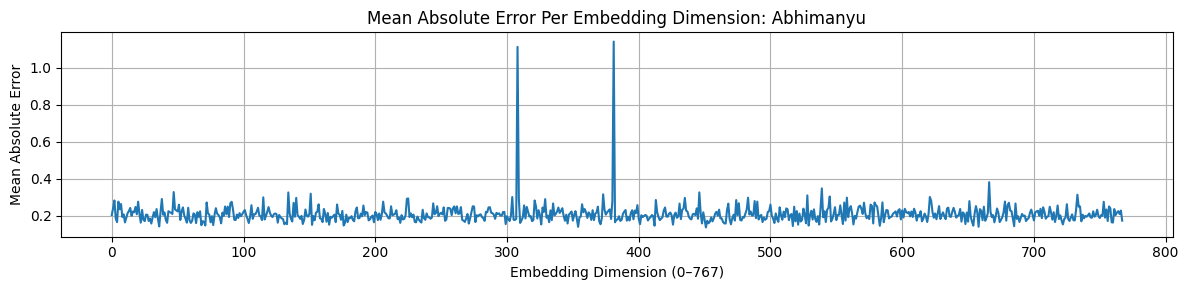

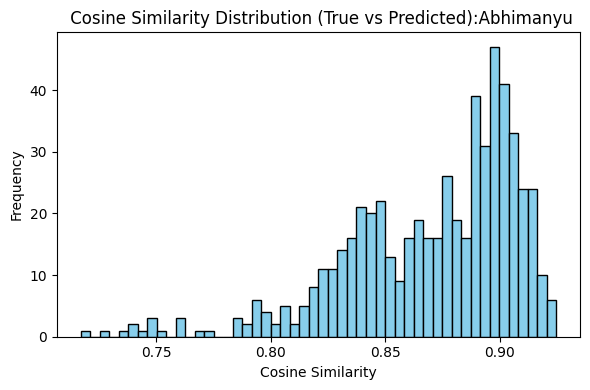

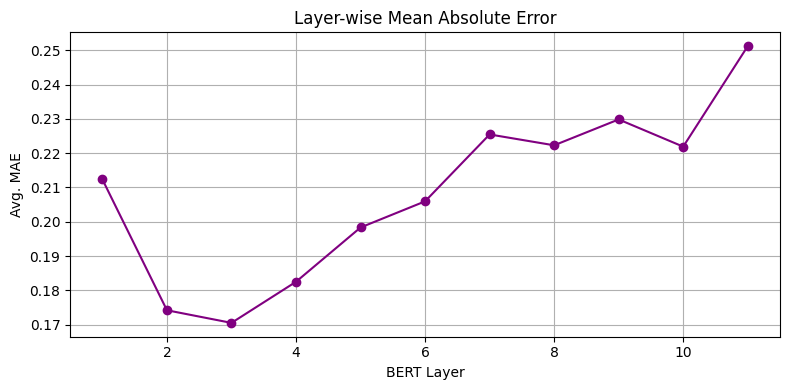

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import numpy as np

# Ensure pred_test and y_true exist (numpy arrays)
abs_error = np.abs(pred_test - y_true)
cosine_similarities = [
    np.dot(p, t) / (np.linalg.norm(p) * np.linalg.norm(t) + 1e-8)
    for p, t in zip(pred_test, y_true)
]

# === Plot 1: Mean Absolute Error Per Dimension ===
plt.figure(figsize=(12, 3))
plt.plot(abs_error.mean(axis=0))
plt.title("Mean Absolute Error Per Embedding Dimension: Abhimanyu")
plt.xlabel("Embedding Dimension (0–767)")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PINN/03.07.25-Output/Abhimanyu_Output/Error_Plot/plot1_mae_per_dim.pdf")
plt.show()

# === Plot 2: Histogram of Cosine Similarity ===
plt.figure(figsize=(6, 4))
plt.hist(cosine_similarities, bins=50, color='skyblue', edgecolor='black')
plt.title(" Cosine Similarity Distribution (True vs Predicted):Abhimanyu")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PINN/03.07.25-Output/Abhimanyu_Output/Error_Plot/plot2_cosine_similarity_hist.pdf")
plt.show()

# === Plot 3: Layer-wise Error if layer index is available in X_test ===
if 'X_test' in globals():
    layer_numbers = [int(x[3]) for x in X_test]  # meta[3] = layer number
    layer_mae = defaultdict(list)

    for err, layer in zip(np.mean(abs_error, axis=1), layer_numbers):
        layer_mae[layer].append(err)

    avg_layer_mae = {k: np.mean(v) for k, v in layer_mae.items()}

    plt.figure(figsize=(8, 4))
    plt.plot(sorted(avg_layer_mae.keys()),
             [avg_layer_mae[k] for k in sorted(avg_layer_mae.keys())],
             marker='o', color='purple')
    plt.title("Layer-wise Mean Absolute Error")
    plt.xlabel("BERT Layer")
    plt.ylabel("Avg. MAE")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/PINN/03.07.25-Output/Abhimanyu_Output/Error_Plot/plot3_layerwise_mae.pdf")
    plt.show()


In [13]:
import os
import json
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
from collections import defaultdict

# === Organize predictions and truths layer-wise ===
layerwise_data = defaultdict(list)
for x, y_pred, y_true_ in zip(X_test, pred_test, y_true):
    layer = int(x[3])  # metadata[3] = layer
    layerwise_data[layer].append((y_pred, y_true_))

# === Compute metrics per layer ===
layerwise_metrics = {}

for layer, pairs in sorted(layerwise_data.items()):
    preds = np.array([p for p, _ in pairs])
    trues = np.array([t for _, t in pairs])

    # Basic metrics
    mse = mean_squared_error(trues, preds)
    mae = mean_absolute_error(trues, preds)
    r2 = r2_score(trues, preds)

    # Cosine similarity (mean across samples)
    cos_sims = [
        np.dot(p, t) / (np.linalg.norm(p) * np.linalg.norm(t) + 1e-8)
        for p, t in zip(preds, trues)
    ]
    mean_cos = np.mean(cos_sims)

    # Pearson correlation (mean across dimensions)
    dim_corrs = [
        pearsonr(preds[:, i], trues[:, i])[0] for i in range(preds.shape[1])
    ]
    mean_pearson = np.nanmean(dim_corrs)  # handle any NaNs

    # Store rounded results
    # Store rounded + serialized-safe results
    layerwise_metrics[int(layer)] = {
        "MSE": round(float(mse), 6),
        "MAE": round(float(mae), 6),
        "R2": round(float(r2), 6),
        "Cosine_Similarity": round(float(mean_cos), 6),
        "Pearson_Corr": round(float(mean_pearson), 6)
    }


# === Final JSON Dict ===
results = {
    "character": "Abhimanyu",
    "split": "parva-wise",
    "layerwise_metrics": layerwise_metrics
}

# === Save to JSON File ===
output_path = "/content/drive/MyDrive/PINN/03.07.25-Output/Abhimanyu_Output/Error_Plot/abhimanyu_parva_layerwise_metrics.json"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"✅ Layer-wise metrics saved to:\n{output_path}")


✅ Layer-wise metrics saved to:
/content/drive/MyDrive/PINN/03.07.25-Output/Abhimanyu_Output/Error_Plot/abhimanyu_parva_layerwise_metrics.json


# **Visualize Prediction for One Sentence for Parvawise split**

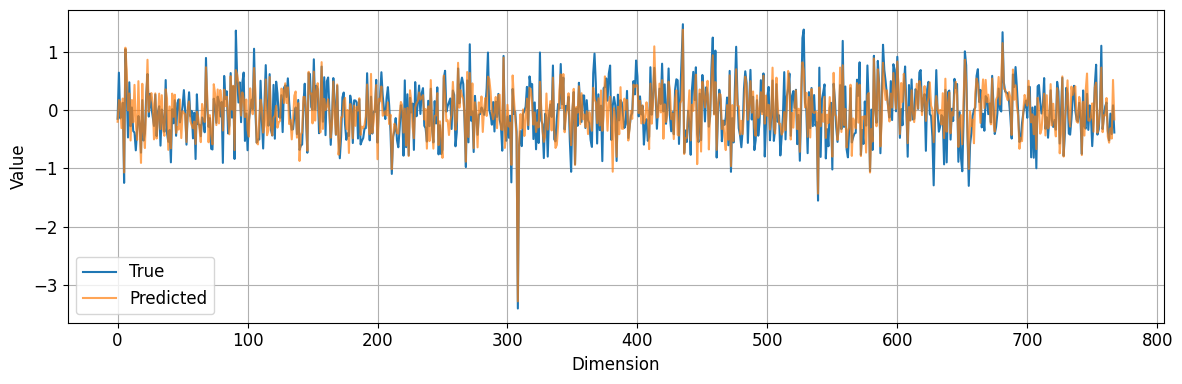

In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.figure(figsize=(12, 4))
plt.plot(true_vec, label="True")
plt.plot(pred_vec, label="Predicted", alpha=0.7)
# plt.title("True vs Predicted Embedding of a Sample Sentence from Parva-wise: Abhimanyu")
plt.xlabel("Dimension")
plt.ylabel("Value")
plt.legend()
plt.grid(True)  # <-- Add grid
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PINN/03.07.25-Output/Abhimanyu_Output/layer_prediction_for_One_Sentence_Parva_Wise_Abhimanyu.pdf")
plt.show()


In [24]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# === Set output directory ===
output_dir = "/content/drive/MyDrive/PINN/03.07.25-Output/Abhimanyu_Output/layerwise_single_sentence"
os.makedirs(output_dir, exist_ok=True)

# === Group test set by (parva, chapter, sentence) ===
test_map = defaultdict(list)
for x, y in zip(X_test, Y_test):
    key = tuple(x[:3])  # (parva, chapter, sentence)
    test_map[key].append((x, y))

# === Select a sentence (e.g., first one) ===
selected_key = list(test_map.keys())[0]
layer_data = sorted(test_map[selected_key], key=lambda z: z[0][3])  # sort by layer

# === Generate 11 layer-wise plots ===
for x, y in layer_data:
    parva, chapter, sentence, layer = map(int, x[:4])
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
    y_true = np.array(y)
    y_pred = model(x_tensor).detach().cpu().numpy()[0]

    # Plot setup
    plt.figure(figsize=(12, 3))
    plt.plot(y_true, label="True", linewidth=1, color='blue')
    plt.plot(y_pred, label="Predicted", linewidth=1, alpha=0.7, color='orange')
    plt.title(f"Layer {layer} → {layer+1} | Parva {parva}, Chapter {chapter}, Sentence {sentence}")
    plt.xlabel("Embedding Dimension (0–767)")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()

    # === Force white background ===
    plt.gcf().set_facecolor("white")
    plt.gca().set_facecolor("white")

    # Save plot
    fname = f"sent_{sentence}_parva_{parva}_chap_{chapter}_layer_{layer}_to_{layer+1}.pdf"
    fpath = os.path.join(output_dir, fname)
    plt.savefig(fpath, facecolor="white")
    plt.close()

print(f"✅ Saved 11 white-background plots for Sentence {sentence} to:\n{output_dir}")


✅ Saved 11 white-background plots for Sentence 170 to:
/content/drive/MyDrive/PINN/03.07.25-Output/Abhimanyu_Output/layerwise_single_sentence


# **Model Save and Load+ Visualizing Smoothness or Semantic Drift across Layers for Parvawise Split**

In [26]:
torch.save(model.state_dict(), "/content/drive/MyDrive/PINN/03.07.25-Output/Abhimanyu_Output/abhimanyu_pinnmodel_parvawise.pt")
print("✅ Model saved as 'abhimanyu_pinnmodel_parvawise.pt'")


✅ Model saved as 'abhimanyu_pinnmodel_parvawise.pt'


In [27]:
model = EmbeddingDynamicsPINN().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/PINN/03.07.25-Output/Abhimanyu_Output/abhimanyu_pinnmodel_parvawise.pt"))
model.eval()
print("✅ Model loaded from 'abhimanyu_pinnmodel_parvawise.pt'")


✅ Model loaded from 'abhimanyu_pinnmodel_parvawise.pt'


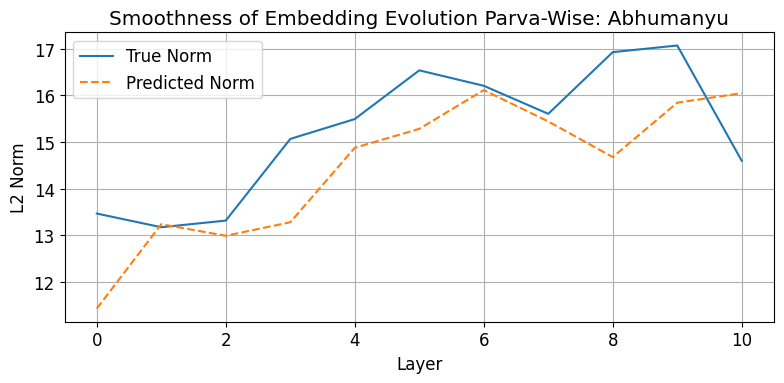

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Group test samples by (parva, chapter, sentence)
test_map = defaultdict(list)
for x, y in zip(X_test, Y_test):
    key = tuple(x[:3])  # parva, chapter, sentence
    test_map[key].append((x, y))

# Pick a sentence (first one in test set)
selected_key = list(test_map.keys())[0]
layerwise_preds = []
layerwise_true = []

# Sort layers (layer 1 to 11, but we will infer up to layer 12)
layer_data = sorted(test_map[selected_key], key=lambda z: z[0][3])  # layer

for x, y in layer_data:
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    pred = model(x_tensor).detach().cpu()
    layerwise_preds.append(pred.squeeze().numpy())
    layerwise_true.append(y_tensor.numpy())

layerwise_preds = np.array(layerwise_preds)
layerwise_true = np.array(layerwise_true)

# Plot L2 norm drift across layers
def plot_norm_drift(true_embs, pred_embs):
    true_norms = np.linalg.norm(true_embs, axis=1)
    pred_norms = np.linalg.norm(pred_embs, axis=1)
    plt.figure(figsize=(8, 4))
    plt.plot(true_norms, label="True Norm")
    plt.plot(pred_norms, label="Predicted Norm", linestyle="--")
    plt.title("Smoothness of Embedding Evolution Parva-Wise: Abhumanyu")
    plt.xlabel("Layer")
    plt.ylabel("L2 Norm")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/PINN/03.07.25-Output/Abhimanyu_Output/Embedding_Evolution/embedding_smoothness_drift_Parva-wise_Abhimanyu.pdf")
    plt.show()

plot_norm_drift(layerwise_true, layerwise_preds)


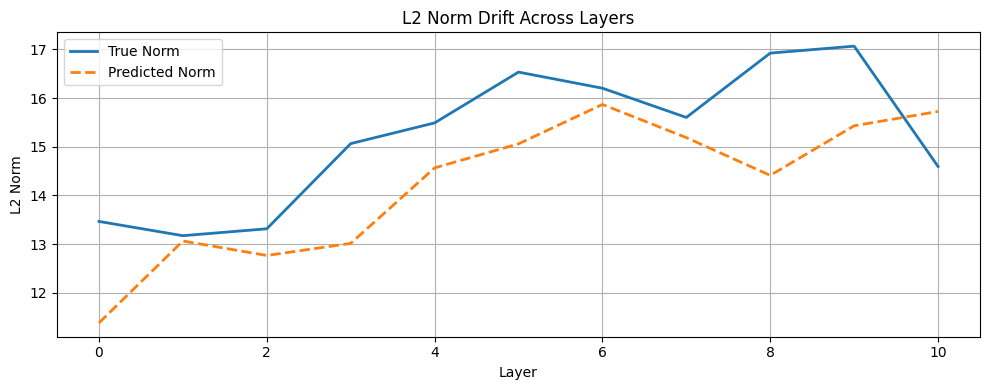

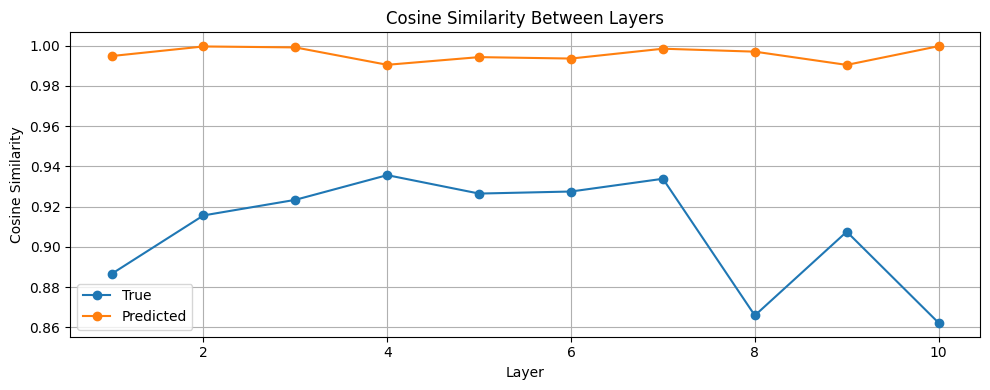

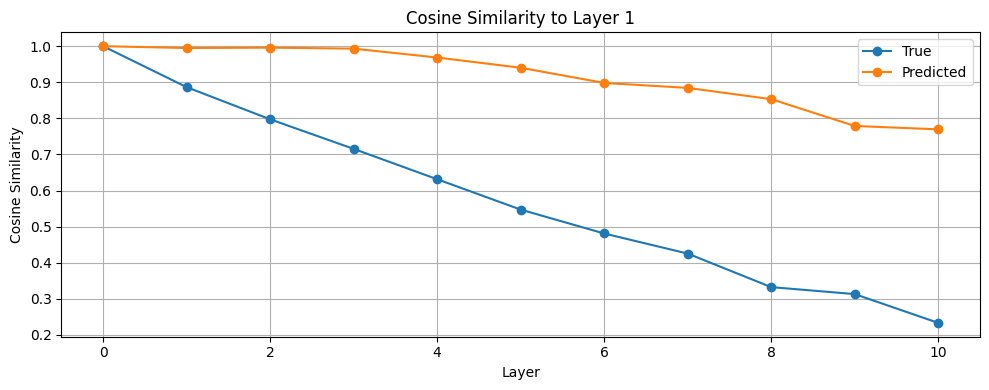

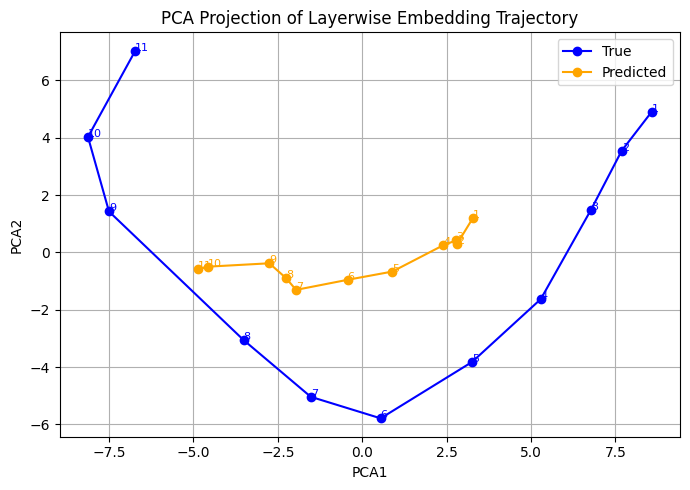

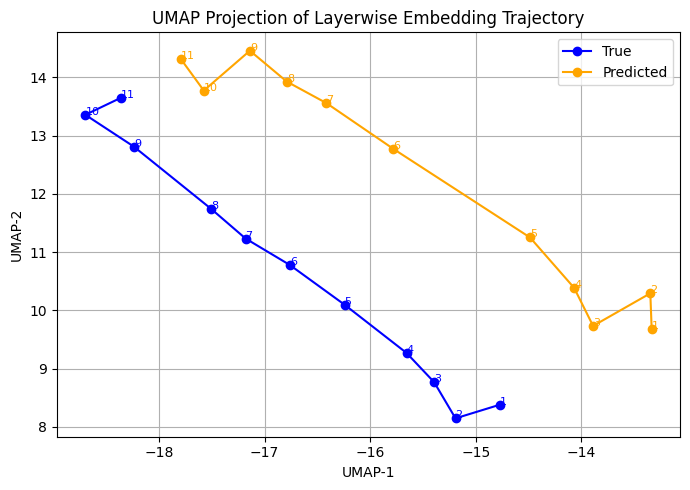

In [50]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from collections import defaultdict
import umap

# === Group test samples by (parva, chapter, sentence) ===
test_map = defaultdict(list)
for x, y in zip(X_test, Y_test):
    key = tuple(x[:3])  # parva, chapter, sentence
    test_map[key].append((x, y))

# === Select one sentence (first one in test set) ===
selected_key = list(test_map.keys())[0]
layerwise_preds = []
layerwise_true = []

# === Sort by layer index ===
layer_data = sorted(test_map[selected_key], key=lambda z: z[0][3])  # by layer

for x, y in layer_data:
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    pred = model(x_tensor).detach().cpu()
    layerwise_preds.append(pred.squeeze().numpy())
    layerwise_true.append(y_tensor.numpy())

layerwise_preds = np.array(layerwise_preds)
layerwise_true = np.array(layerwise_true)

# === Plot 1: L2 Norm Drift ===
def plot_norm_drift(true_embs, pred_embs):
    true_norms = np.linalg.norm(true_embs, axis=1)
    pred_norms = np.linalg.norm(pred_embs, axis=1)
    plt.plot(true_norms, label="True Norm", linewidth=2)
    plt.plot(pred_norms, label="Predicted Norm", linestyle="--", linewidth=2)
    plt.title("L2 Norm Drift Across Layers")
    plt.xlabel("Layer")
    plt.ylabel("L2 Norm")
    plt.legend()
    plt.grid(True)

# === Plot 2: Cosine Similarity Between Layers ===
def plot_cosine_similarity_trend(embs, label):
    similarities = []
    for i in range(len(embs) - 1):
        cos = cosine_similarity([embs[i]], [embs[i + 1]])[0][0]
        similarities.append(cos)
    plt.plot(range(1, len(similarities) + 1), similarities, marker='o', label=label)
    plt.title("Cosine Similarity Between Layers")
    plt.xlabel("Layer")
    plt.ylabel("Cosine Similarity")
    plt.grid(True)

# === Plot 3: Cosine Similarity to Layer 1 ===
def plot_cosine_to_first(embs, label):
    first = embs[0]
    sims = [cosine_similarity([first], [e])[0][0] for e in embs]
    plt.plot(sims, marker='o', label=label)
    plt.title("Cosine Similarity to Layer 1")
    plt.xlabel("Layer")
    plt.ylabel("Cosine Similarity")
    plt.grid(True)

# === Plot 4: PCA Trajectory ===
def plot_pca_trajectory(true_embs, pred_embs):
    all_embs = np.vstack([true_embs, pred_embs])
    pca = PCA(n_components=2)
    projected = pca.fit_transform(all_embs)

    n = len(true_embs)
    plt.plot(projected[:n, 0], projected[:n, 1], '-o', label="True", color='blue')
    plt.plot(projected[n:, 0], projected[n:, 1], '-o', label="Predicted", color='orange')
    for i in range(n):
        plt.text(projected[i, 0], projected[i, 1], str(i + 1), fontsize=8, color='blue')
        plt.text(projected[n + i, 0], projected[n + i, 1], str(i + 1), fontsize=8, color='orange')
    plt.title("PCA Projection of Layerwise Embedding Trajectory")
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.grid(True)
    plt.legend()

# === Plot 5: UMAP Trajectory ===
def plot_umap_trajectory(true_embs, pred_embs):
    all_embs = np.vstack([true_embs, pred_embs])
    reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, metric='cosine', random_state=42)
    projected = reducer.fit_transform(all_embs)

    n = len(true_embs)
    plt.plot(projected[:n, 0], projected[:n, 1], '-o', label="True", color='blue')
    plt.plot(projected[n:, 0], projected[n:, 1], '-o', label="Predicted", color='orange')
    for i in range(n):
        plt.text(projected[i, 0], projected[i, 1], str(i + 1), fontsize=8, color='blue')
        plt.text(projected[n + i, 0], projected[n + i, 1], str(i + 1), fontsize=8, color='orange')
    plt.title("UMAP Projection of Layerwise Embedding Trajectory")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.grid(True)
    plt.legend()

# === Create Dashboard ===
plt.figure(figsize=(10, 4))
plot_norm_drift(layerwise_true, layerwise_preds)
plt.tight_layout()
plt.savefig("1_norm_drift.pdf")
plt.show()

plt.figure(figsize=(10, 4))
plot_cosine_similarity_trend(layerwise_true, "True")
plot_cosine_similarity_trend(layerwise_preds, "Predicted")
plt.legend()
plt.tight_layout()
plt.savefig("2_cosine_similarity_drift.pdf")
plt.show()

plt.figure(figsize=(10, 4))
plot_cosine_to_first(layerwise_true, "True")
plot_cosine_to_first(layerwise_preds, "Predicted")
plt.legend()
plt.tight_layout()
plt.savefig("3_cosine_to_layer1.pdf")
plt.show()

plt.figure(figsize=(7, 5))
plot_pca_trajectory(layerwise_true, layerwise_preds)
plt.tight_layout()
plt.savefig("4_pca_trajectory.pdf")
plt.show()

plt.figure(figsize=(7, 5))
plot_umap_trajectory(layerwise_true, layerwise_preds)
plt.tight_layout()
plt.savefig("5_umap_trajectory.pdf")
plt.show()


# **Generate Animated Embedding Stream**

In [39]:
!apt install -y ffmpeg


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


✅ Animation saved to embedding_stream_with_velocity.mp4


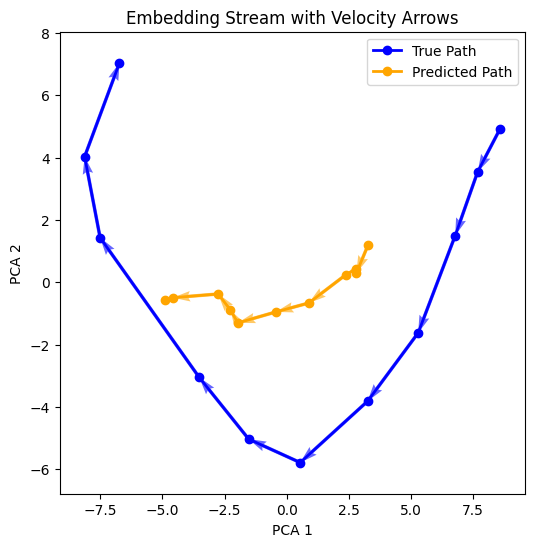

In [41]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.decomposition import PCA
from collections import defaultdict

# === Step 1: Prepare layerwise embeddings (true and predicted) ===
test_map = defaultdict(list)
for x, y in zip(X_test, Y_test):
    key = tuple(x[:3])  # parva, chapter, sentence
    test_map[key].append((x, y))

# Pick one sentence
selected_key = list(test_map.keys())[0]
layer_data = sorted(test_map[selected_key], key=lambda z: z[0][3])  # sort by layer index

layerwise_preds = []
layerwise_true = []

for x, y in layer_data:
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    pred = model(x_tensor).detach().cpu()
    layerwise_preds.append(pred.squeeze().numpy())
    layerwise_true.append(y_tensor.numpy())

layerwise_preds = np.array(layerwise_preds)
layerwise_true = np.array(layerwise_true)

# === Step 2: PCA Projection ===
all_embs = np.vstack([layerwise_true, layerwise_preds])
pca = PCA(n_components=2)
all_proj = pca.fit_transform(all_embs)

true_proj = all_proj[:len(layerwise_true)]
pred_proj = all_proj[len(layerwise_true):]

# Compute displacements (velocities) between layers
true_vel = true_proj[1:] - true_proj[:-1]
pred_vel = pred_proj[1:] - pred_proj[:-1]

# === Step 3: Create animated plot with quivers ===
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(np.min(all_proj[:, 0]) - 1, np.max(all_proj[:, 0]) + 1)
ax.set_ylim(np.min(all_proj[:, 1]) - 1, np.max(all_proj[:, 1]) + 1)
ax.set_title("Embedding Stream with Velocity Arrows")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")

true_line, = ax.plot([], [], 'o-', lw=2, color='blue', label='True Path')
pred_line, = ax.plot([], [], 'o-', lw=2, color='orange', label='Predicted Path')

true_quivers = []
pred_quivers = []

ax.legend()

def init():
    true_line.set_data([], [])
    pred_line.set_data([], [])
    return true_line, pred_line

def animate(i):
    # Clear previous arrows
    for q in true_quivers + pred_quivers:
        q.remove()
    true_quivers.clear()
    pred_quivers.clear()

    # Update trajectories
    true_line.set_data(true_proj[:i+1, 0], true_proj[:i+1, 1])
    pred_line.set_data(pred_proj[:i+1, 0], pred_proj[:i+1, 1])

    # Add velocity arrows (quivers)
    for j in range(i):
        tq = ax.quiver(true_proj[j, 0], true_proj[j, 1],
                       true_vel[j, 0], true_vel[j, 1],
                       angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.6)
        pq = ax.quiver(pred_proj[j, 0], pred_proj[j, 1],
                       pred_vel[j, 0], pred_vel[j, 1],
                       angles='xy', scale_units='xy', scale=1, color='orange', alpha=0.6)
        true_quivers.append(tq)
        pred_quivers.append(pq)

    return true_line, pred_line, *true_quivers, *pred_quivers

ani = animation.FuncAnimation(fig, animate, init_func=init,
                              frames=len(true_proj), interval=800, blit=True)

# === Save or show ===
ani.save("embedding_stream_with_velocity.mp4", writer='ffmpeg')
print("✅ Animation saved to embedding_stream_with_velocity.mp4")

# === Optional: inline display in notebooks ===
# from IPython.display import HTML
# HTML(ani.to_jshtml())


✅ Animation saved to embedding_stream_umap.html


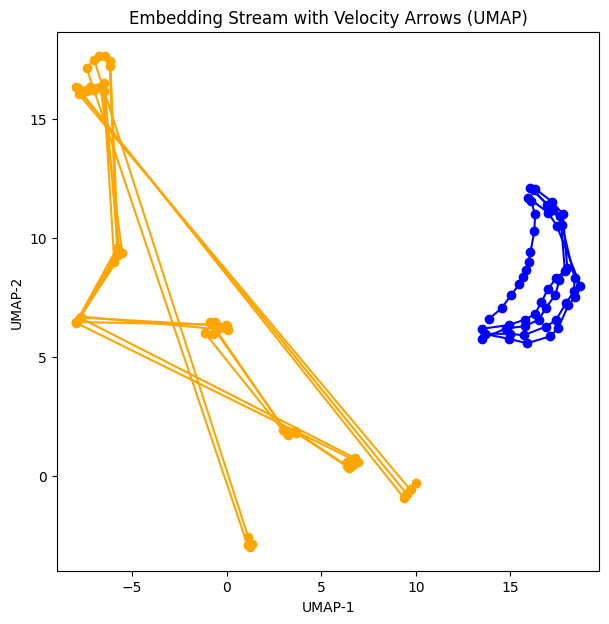

In [43]:
import torch
import numpy as np
import umap
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from collections import defaultdict
from IPython.display import HTML
import matplotlib.cm as cm

# === STEP 1: Prepare embeddings for multiple test sentences ===
max_sentences = 5  # Number of sentences to animate
test_map = defaultdict(list)
for x, y in zip(X_test, Y_test):
    key = tuple(x[:3])  # (parva, chapter, sentence)
    test_map[key].append((x, y))

selected_keys = list(test_map.keys())[:max_sentences]
all_true, all_pred, sentence_ids = [], [], []

for sid, key in enumerate(selected_keys):
    layer_data = sorted(test_map[key], key=lambda z: z[0][3])  # sort by layer

    true_layers, pred_layers = [], []
    for x, y in layer_data:
        x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
        pred = model(x_tensor).detach().cpu().squeeze().numpy()
        true_layers.append(np.array(y))
        pred_layers.append(pred)

    all_true.append(true_layers)
    all_pred.append(pred_layers)
    sentence_ids.append([sid] * len(true_layers))

all_true = np.array(all_true)    # (S, L, 768)
all_pred = np.array(all_pred)    # (S, L, 768)
sentence_ids = np.array(sentence_ids)

# === STEP 2: Project all embeddings to 2D using UMAP ===
S, L, D = all_true.shape
flat_true = all_true.reshape(-1, D)     # (S*L, 768)
flat_pred = all_pred.reshape(-1, D)     # (S*L, 768)
flat_embeddings = np.vstack([flat_true, flat_pred])  # (2*S*L, 768)

umap_model = umap.UMAP(n_neighbors=5, min_dist=0.3, metric='cosine', random_state=42)
umap_proj = umap_model.fit_transform(flat_embeddings)

true_proj = umap_proj[:S*L].reshape(S, L, 2)        # (S, L, 2)
pred_proj = umap_proj[S*L:].reshape(S, L, 2)        # (S, L, 2)

# === STEP 3: Animate with UMAP trajectories and velocity arrows ===
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_title("Embedding Stream with Velocity Arrows (UMAP)")
ax.set_xlim(np.min(umap_proj[:, 0]) - 1, np.max(umap_proj[:, 0]) + 1)
ax.set_ylim(np.min(umap_proj[:, 1]) - 1, np.max(umap_proj[:, 1]) + 1)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")

colors = cm.viridis(np.linspace(0, 1, L-1))  # Gradient color by layer

lines_true = [ax.plot([], [], 'o-', lw=1.5, color='blue')[0] for _ in range(S)]
lines_pred = [ax.plot([], [], 'o-', lw=1.5, color='orange')[0] for _ in range(S)]
quivers_true, quivers_pred = [], []

def init():
    for line in lines_true + lines_pred:
        line.set_data([], [])
    return lines_true + lines_pred

def animate(i):
    for q in quivers_true + quivers_pred:
        q.remove()
    quivers_true.clear()
    quivers_pred.clear()

    for s in range(S):
        lines_true[s].set_data(true_proj[s, :i+1, 0], true_proj[s, :i+1, 1])
        lines_pred[s].set_data(pred_proj[s, :i+1, 0], pred_proj[s, :i+1, 1])

        if i < L - 1:
            dx_true = true_proj[s, i+1, 0] - true_proj[s, i, 0]
            dy_true = true_proj[s, i+1, 1] - true_proj[s, i, 1]
            dx_pred = pred_proj[s, i+1, 0] - pred_proj[s, i, 0]
            dy_pred = pred_proj[s, i+1, 1] - pred_proj[s, i, 1]

            tq = ax.quiver(true_proj[s, i, 0], true_proj[s, i, 1],
                           dx_true, dy_true,
                           angles='xy', scale_units='xy', scale=1,
                           color=colors[i], alpha=0.8)

            pq = ax.quiver(pred_proj[s, i, 0], pred_proj[s, i, 1],
                           dx_pred, dy_pred,
                           angles='xy', scale_units='xy', scale=1,
                           color=colors[i], alpha=0.8)

            quivers_true.append(tq)
            quivers_pred.append(pq)

    return lines_true + lines_pred + quivers_true + quivers_pred

ani = animation.FuncAnimation(fig, animate, init_func=init,
                              frames=L, interval=1000, blit=True)

# === STEP 4: Export to HTML ===
html_anim = ani.to_jshtml()
with open("embedding_stream_umap.html", "w") as f:
    f.write(html_anim)

print("✅ Animation saved to embedding_stream_umap.html")

# Optional: show inline in notebook (Jupyter or Colab)
HTML(html_anim)
